# **Assessment 12: Introduction to NLP & Text Preprocessing**

**Submitted by:**
* Benedict S. Caliba
* Marcelo B. Cosme
* Aaron Kane M. Dungca
  
**Date Submitted:** May 9, 2026

---

In [32]:
# Install/download required resources
#!pip install nltk spacy scikit-learn
#!python -m spacy download en_core_web_sm
!pip install gensim

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import re
import string
from collections import Counter
import spacy
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from nltk.stem import WordNetLemmatizer

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, 
    adjusted_rand_score, 
    normalized_mutual_info_score
)

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

import matplotlib.patches as mpatches


# Download NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

print("All libraries loaded!")

  Using cached gensim-4.4.0.tar.gz (23.3 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build gensim


  error: subprocess-exited-with-error
  
  exit code: 1
  
  [716 lines of output]
  C:\Users\dungc\AppData\Local\Temp\pip-build-env-pg4pi2jz\overlay\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'test_suite'
    warnings.warn(msg)
  C:\Users\dungc\AppData\Local\Temp\pip-build-env-pg4pi2jz\overlay\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'tests_require'
    warnings.warn(msg)
  running bdist_wheel
  running build
  running build_py
  creating build\lib.win-amd64-cpython-314\gensim
  copying gensim\downloader.py -> build\lib.win-amd64-cpython-314\gensim
  copying gensim\interfaces.py -> build\lib.win-amd64-cpython-314\gensim
  copying gensim\matutils.py -> build\lib.win-amd64-cpython-314\gensim
  copying gensim\nosy.py -> build\lib.win-amd64-cpython-314\gensim
  copying gensim\utils.py -> build\lib.win-amd64-cpython-314\gensim
  copying gensim\__init__.py -> build\lib.win-amd64-cpython

ModuleNotFoundError: No module named 'gensim'

# **Data Loading & Exploration**

In [2]:
# Load the dataset
df = pd.read_csv("IMDB Dataset.csv")
print(df.columns)

Index(['review', 'sentiment'], dtype='str')


In [3]:
print("First five rows:")
print(df.head())
print(f"\nDataset shape: {df.shape}")

First five rows:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Dataset shape: (50000, 2)


### **Check if dataset is imbalanced**

In [4]:
print(df['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


**Insights:**\
The IMDB dataset is evenly balanced.

### **Compare sentiment word counts**

In [5]:
df['word_count'] = df['review'].apply(lambda x: len(x.split()))
print(df.groupby('sentiment')['word_count'].mean())

sentiment
negative    229.46456
positive    232.84932
Name: word_count, dtype: float64


**Insights:**\
The group that tends to write longer reviews are people who have a negative sentiment about the movie. This is because people who disliked the movie tend to be more critical about what they didn't like about the film, compared to people who more or less enjoyed it.

In [6]:
for sentiment in ['positive', 'negative']:
    print(f"\n--- {sentiment.upper()} REVIEWS ---")
    samples = df[df['sentiment'] == sentiment]['review'].sample(2, random_state=42)
    for i, review in enumerate(samples, 1):
        print(f"\nSample {i}:\n{review[:300]}...")


--- POSITIVE REVIEWS ---

Sample 1:
I don't know how or why this film has a meager rating on IMDb. This film, accompanied by "I am Curious: Blue" is a masterwork.<br /><br />The only thing that will let you down in this film is if you don't like the process of film, don't like psychology or if you were expecting hardcore pornographic ...

Sample 2:
For a long time it seemed like all the good Canadian actors had headed south of the border and (I guessed) all the second rank ones filled the top slots and that left the dregs for the sex comedies.<br /><br />This film was a real surprise: despite the outlandish plots that are typical of farces, th...

--- NEGATIVE REVIEWS ---

Sample 1:
I was looking forward to seeing Bruce Willis in this, especially since I remember being mesmerised by the original when I was young.<br /><br />This movie is a perfect example of how movie companies can take a very good story and dumb it down until it's just another formula ridden hype of the fabled...

Sa

**Insights**\
Based on the two sample reviews from both groups, they read like a typical movie review talking about the things they enjoyed (or didn't enjoy) about the movie, the actors, personal experiences, etc. It also uses words such as "don't", "good", "bad", "good", etc. which mostly dictate the emotion that the reviewer wants to convey about the movie.

# **Text Cleaning & Tokenization**

## **Text Cleaning**

In [7]:
def clean_text(text):
    # Remove Lowercase
    text = text.lower()
    # Remove html tags
    text = re.sub(r'<br\s*/>', ' ', text)
    # Remove punctuation and numbers
    text = re.sub(r'[^\w\s]|\d+\.?\d*', '', text)
    # Strip extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned'] = df['review'].apply(clean_text)
print(f'Original: \n{df['review'][67]}')
print(f'\nCleaned: \n{df['cleaned'][67]}')

Original: 
I really like Salman Kahn so I was really disappointed when I seen this movie. It didn't have much of a plot and what they did have was not that appealing. Salman however did look good in the movie looked young and refreshed but was worth the price of this DVD. The music was not bad it was quite nice. Usually Indian movies are at least two to three hours long but this was a very short movie for an Indian film. The American actress that played in the movie is from the television hit series Heroes, Ali Larter. Her acting had a lot to be desired. However she did look good in the Indian dresses that she wore. All the movie had not a lot to be desired and I hope Salman does a lot better on his next movie. Thank you.

Cleaned: 
i really like salman kahn so i was really disappointed when i seen this movie it didnt have much of a plot and what they did have was not that appealing salman however did look good in the movie looked young and refreshed but was worth the price of this dvd

### **Stop word removal**

In [8]:
# Stop word removal
stop_words = set(stopwords.words('english'))

# Tokenize full DataFrame
df['tokens'] = df['cleaned'].apply(word_tokenize)

# Demo on a single review
sample_tokens = df['tokens'].iloc[0]
filtered_sample = [w for w in sample_tokens if w not in stop_words]

print(f"Before stop word removal ({len(sample_tokens)} tokens):")
print(f'{sample_tokens[:30]}...')
print(f"\nAfter stop word removal ({len(filtered_sample)} tokens):")
print(f'{filtered_sample[:30]}...')
print(f"\nRemoved {len(sample_tokens) - len(filtered_sample)} stop words")

# Apply to full DataFrame
df['filtered_tokens'] = df['tokens'].apply(
    lambda tokens: [w for w in tokens if w not in stop_words]
)

Before stop word removal (303 tokens):
['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', 'youll', 'be', 'hooked', 'they', 'are', 'right', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'me', 'the', 'first', 'thing']...

After stop word removal (166 tokens):
['one', 'reviewers', 'mentioned', 'watching', 'oz', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scenes', 'violence', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'hearted', 'timid', 'show', 'pulls']...

Removed 137 stop words


### **Print top 20 most frequent tokens**

In [9]:
# Flatten all tokens into one list
all_tokens = [token for tokens in df['filtered_tokens'] for token in tokens]

# Count and display top 20
token_counts = Counter(all_tokens)
print("Top 20 most frequent tokens:")
for word, count in token_counts.most_common(20):
    print(f"  {word:<15} {count:>7}")

print(f"Total tokens:  {sum(token_counts.values())}")
print(f"Unique tokens: {len(token_counts)}")

Top 20 most frequent tokens:
  movie             85234
  film              76033
  one               51480
  like              39066
  good              28913
  even              24586
  would             24036
  time              23970
  really            23014
  see               22641
  story             22519
  well              19234
  much              19109
  get               18244
  bad               18004
  great             17936
  also              17859
  people            17710
  first             17207
  dont              16976
Total tokens:  5948863
Unique tokens: 162627


#### **Create custom stop word list and re-filter**

|**Generic Tokens**|**Count**|
|---|---|
|1. movie|85234|
|2. film|76033|
|3. one|51480|
|4. even|24586|
|5. would|24036|
|6. time|23970|
|7. really|23014|
|8. see|22641
|9. much|19109|
|10. get|18244|
|11. also|17859|
|12. first|17207|


In [10]:
# Create custom stop list
custom_stop_words = {'movie', 'film', 'one', 'even', 'would', 'time', 'really', 'much', 'get', 'also', 'first', 'see'}

# Combine with NLTK stop words
all_stop_words = stop_words | custom_stop_words  # union of both sets

# Re-filter
df['filtered_tokens'] = df['filtered_tokens'].apply(
    lambda tokens: [w for w in tokens if w not in all_stop_words]
)

# Verify — recheck top 20
all_tokens = [token for tokens in df['filtered_tokens'] for token in tokens]
token_counts = Counter(all_tokens)
print("\nTop 20 after custom stop word removal:")
for word, count in token_counts.most_common(20):
    print(f"  {word:<15} {count:>7}")

print(f"Total tokens (after filtering):  {sum(token_counts.values())}")
print(f"Unique tokens (after filtering): {len(token_counts)}")


Top 20 after custom stop word removal:
  like              39066
  good              28913
  story             22519
  well              19234
  bad               18004
  great             17936
  people            17710
  dont              16976
  movies            15722
  made              15559
  films             15539
  way               15373
  make              15329
  could             15174
  characters        14900
  think             14273
  watch             13771
  many              13390
  seen              13302
  two               13084
Total tokens (after filtering):  5545450
Unique tokens (after filtering): 162615


## **Before-and-after Table**

In [11]:
for i in range(0, 3):
    print('=' * 30)
    print(f'REVIEW {i+1} - Sentiment: {df['sentiment'].iloc[i]}')
    print('=' * 30)
    print(f'Original: \n{df['review'].iloc[i][:300]}...')
    print('')
    print(f'Cleaned: \n{df['cleaned'].iloc[i][:300]}...')
    print('')
    print(f'Final Tokens: \n{df['filtered_tokens'].iloc[i][:20]}...')
    print(f'(first 20 tokens out of {len(df['filtered_tokens'].iloc[i]) } total)')

REVIEW 1 - Sentiment: positive
Original: 
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru...

Cleaned: 
one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a...

Final Tokens: 
['reviewers', 'mentioned', 'watching', 'oz', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scenes', 'violence', 'set', 'right', 'word']...
(first 20 tokens out of 160 total)
REVIEW 2 - Sentiment: positive
Original: 
A wonderful little production. <br />

# **Stemming vs. Lemmatization**

## **Porter Stemming**

In [12]:
porter = PorterStemmer()
snowball = SnowballStemmer('english')

# Random sample of 300 reviews
sample_df = df.sample(300, random_state=42).copy()

# Apply porter stemmer
sample_df['stemmed_porter'] = sample_df['filtered_tokens'].apply(
    lambda tokens: [porter.stem(t) for t in tokens]
)

# Comparison table using sample_df tokens
sample_words = sample_df['filtered_tokens'].iloc[0][:10]

print(f"{'Word':<20} {'Porter':<20}")
print("-" * 60)
for word in sample_words:
    print(f"{word:<20} {porter.stem(word):<20}")

Word                 Porter              
------------------------------------------------------------
liked                like                
summerslam           summerslam          
due                  due                 
look                 look                
arena                arena               
curtains             curtain             
look                 look                
overall              overal              
interesting          interest            
reason               reason              


## **spaCy Lemmatization**

In [13]:
subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"], check=True)
nlp = spacy.load('en_core_web_sm')

# Get a single review as a string
sample_text = df['cleaned'].iloc[0]

# Process with spaCy
doc = nlp(sample_text)

# Show first 15 tokens only
print(f"{'Token':<15} {'Lemma':<15} {'POS':<10} {'Is Stop?':<10}")
print("-" * 50)
for token in list(doc)[:15]:
    print(f"{token.text:<15} {token.lemma_:<15} {token.pos_:<10} {str(token.is_stop):<10}")

Token           Lemma           POS        Is Stop?  
--------------------------------------------------
one             one             NUM        True      
of              of              ADP        True      
the             the             DET        True      
other           other           ADJ        True      
reviewers       reviewer        NOUN       False     
has             have            AUX        True      
mentioned       mention         VERB       False     
that            that            SCONJ      True      
after           after           ADP        True      
watching        watch           VERB       False     
just            just            ADV        True      
oz              oz              ADP        False     
episode         episode         NOUN       False     
you             you             PRON       True      
ll              ll              AUX        False     


## **Comparison Table: Porter vs. spaCy Lemma**

In [14]:
comparison_words = sample_df['filtered_tokens'].iloc[0][:10]

print(f"{'Word':<12} {'Porter Stem':<16} {'spaCy Lemma':<16}")
print("-" * 44)
for word in comparison_words:
    doc = nlp(word)
    lemma = doc[0].lemma_
    stem = porter.stem(word)

    if stem == lemma:
        continue
    
    print(f"{word:<12} {stem:<16} {lemma:<16}")

Word         Porter Stem      spaCy Lemma     
--------------------------------------------
overall      overal           overall         
interesting  interest         interesting     


<div style="text-align: center;"><strong>Common stemming and lemmatization diverging outputs:</strong></div>

|**Word**|**Porter**|**Lemma**|
|--|--|--|
|movie|movi|movie|
|im|im|I|
|made|made|make|
|every|everi|every|
|story|stori|story|
|really|realli|really|
|nothing|noth|nothing|
|theyve|theyv|they|
|overall|overal|overall|
|interesting|interest|interesting|

#### **Insights:**<br>
Movie reviews use strong evaluative language — words like "amazing", "terrible", "worst", "loved". Does stemming or lemmatization preserve these sentiment-carrying words better? Explain in 2–3 sentences.
- Based on what we've observed, lemmatization is able to better preserve sentimental words better than stemming.
- Stemming chops off suffixes using rules creating words that may or may not exist.
- Lemmatization on the other hand always looks up words in the actual vocabulary, meaning it is more accurate when preserving these sentiment words.

# **TF-IDF Vectorization & Top Terms per Sentiment**

## **Build a TF-IDF matrix**

In [15]:
# Join filtered tokens back into strings
sample_df['joined'] = sample_df['filtered_tokens'].apply(lambda tokens: ' '.join(tokens))

# Build TF-IDF matrix
vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1,2))
tfidf_matrix = vectorizer.fit_transform(sample_df['joined'])

# Print shape
print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")

TF-IDF Matrix Shape: (300, 500)


### **Print top 10 TF-IDF terms**

In [16]:
# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Convert to dense array
tfidf_array = tfidf_matrix.toarray()

# Add tfidf scores to sample_df
sample_df['tfidf_scores'] = list(tfidf_array)

# Loop through each sentiment
for sentiment in ['positive', 'negative']:
    mask = sample_df['sentiment'] == sentiment
    group_tfidf = tfidf_array[mask.values]
    
    # Average TF-IDF scores across all documents in group
    mean_scores = group_tfidf.mean(axis=0)
    
    # Get top 10 indices
    top10_indices = mean_scores.argsort()[::-1][:10]
    
    print(f"\nTop 10 TF-IDF terms — {sentiment}")
    print("=" * 35)
    for i in top10_indices:
        print(f"  {feature_names[i]:<25} {mean_scores[i]:.4f}")


Top 10 TF-IDF terms — positive
  great                     0.0416
  best                      0.0412
  like                      0.0411
  well                      0.0392
  love                      0.0381
  good                      0.0378
  show                      0.0372
  story                     0.0354
  many                      0.0318
  films                     0.0312

Top 10 TF-IDF terms — negative
  bad                       0.0561
  like                      0.0554
  good                      0.0428
  made                      0.0390
  make                      0.0361
  movies                    0.0350
  plot                      0.0349
  story                     0.0347
  seen                      0.0341
  dont                      0.0334


#### **Insights:**<br>
Identify at least one bigram in the top terms per sentiment and explain why it captures meaning better than its individual words alone (e.g., "special effects" vs. "special" and "effects" separately).
- ``Great Story`` - Direct unambiguous acclaim on the story
- ``Bad Plot`` - Negative connotation about the movie's plot, better than either word on its own 

Do the top positive and negative terms match your intuition about what makes a good or bad movie review? Discuss briefly.
- Yes, these bigrams help me identify a specific aspect of the movie that makes it good or bad.
- A great story and a bad plot is always talked about in movie reviews.

# **Document Similarity**

In [17]:
# Compute cosine similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix)

print(f"Cosine Similarity Matrix Shape: {cosine_sim.shape}")
print(f"\nSample (5x5 top-left corner):")
print(cosine_sim[:5, :5].round(4))

Cosine Similarity Matrix Shape: (300, 300)

Sample (5x5 top-left corner):
[[1.     0.0364 0.0196 0.03   0.052 ]
 [0.0364 1.     0.0686 0.0184 0.0819]
 [0.0196 0.0686 1.     0.     0.0739]
 [0.03   0.0184 0.     1.     0.    ]
 [0.052  0.0819 0.0739 0.     1.    ]]


Chosen negative review: ``0.0184``
1. ``0.0184``
2. ``0.03``
3. ``0.03``

In [18]:
# Pick a negative review
negative_indices = sample_df[sample_df['sentiment'] == 'negative'].index
chosen_idx = negative_indices[0]
chosen_pos = sample_df.index.get_loc(chosen_idx)

# Get similarity scores and exclude itself
sim_scores = cosine_sim[chosen_pos].copy()
sim_scores[chosen_pos] = -1
top3_indices = sim_scores.argsort()[::-1][:3]

# Print chosen review
print(f"Chosen Review (NEGATIVE) | Similarity: {cosine_sim[chosen_pos][chosen_pos]:.4f}")
print(f"{sample_df['review'].iloc[chosen_pos][:150]}...")
print(f"\n{'='*60}")
print(f"Top 3 Most Similar Reviews:")
print(f"{'='*60}")

for rank, idx in enumerate(top3_indices, 1):
    sentiment = sample_df['sentiment'].iloc[idx]
    review_text = sample_df['review'].iloc[idx][:150]
    similarity = cosine_sim[chosen_pos][idx]
    print(f"\nRank {rank} | Sentiment: {sentiment.upper()} | Similarity: {similarity:.4f}")
    print(f"{review_text}...")

Chosen Review (NEGATIVE) | Similarity: 1.0000
The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy hijacking Steven Seagal would hav...

Top 3 Most Similar Reviews:

Rank 1 | Sentiment: POSITIVE | Similarity: 0.2637
Sunday would not be Sunday without an action movie, and when you want intense combat, you turn to Tom Berenger (Platoon).<br /><br />Here he plays a s...

Rank 2 | Sentiment: NEGATIVE | Similarity: 0.2612
OK, I wanted to see this because it had a few good reviews, but this movie was awful... Just plain awful. The characters were 1 dimensional and nothin...

Rank 3 | Sentiment: NEGATIVE | Similarity: 0.2450
There is a DVD published in the UK in 2002 Code HRGD002 on the cover, no ASIN, VFC 19796 on the disk, no IFPI code in the inner rim.<br /><br />Probab...


#### **Insights:**

Discussing this briefly, only one review that is similar to the chosen review was positive as opposed to negative. This may be because the chosen review was an action movie, meaning other action movies are also similar to the film.

Chosen positive review: ``1.00``
1. ``0.0819``
2. ``0.0819``
3. ``0.0739``

In [19]:
# Pick a positive review
positive_indices = sample_df[sample_df['sentiment'] == 'positive'].index
chosen_idx = positive_indices[0]
chosen_pos = sample_df.index.get_loc(chosen_idx)

# Get similarity scores and exclude itself
sim_scores = cosine_sim[chosen_pos].copy()
sim_scores[chosen_pos] = -1
top3_indices = sim_scores.argsort()[::-1][:3]

# Print chosen review
print(f"Chosen Review (POSITIVE) | Similarity: {cosine_sim[chosen_pos][chosen_pos]:.4f}")
print(f"{sample_df['review'].iloc[chosen_pos][:150]}...")
print(f"\n{'='*60}")
print(f"Top 3 Most Similar Reviews:")
print(f"{'='*60}")

for rank, idx in enumerate(top3_indices, 1):
    sentiment = sample_df['sentiment'].iloc[idx]
    review_text = sample_df['review'].iloc[idx][:150]
    similarity = cosine_sim[chosen_pos][idx]
    print(f"\nRank {rank} | Sentiment: {sentiment.upper()} | Similarity: {similarity:.4f}")
    print(f"{review_text}...")

Chosen Review (POSITIVE) | Similarity: 1.0000
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, th...

Top 3 Most Similar Reviews:

Rank 1 | Sentiment: NEGATIVE | Similarity: 0.2961
I was browsing through the movies on demand and saw Underdog for free and it was only 82 minutes long so I decided to watch it. I wasn't expecting muc...

Rank 2 | Sentiment: NEGATIVE | Similarity: 0.2181
I'm just filling this comment out, because I couldn't stand the fact that a positive comment was featured on the "complete information" page. I really...

Rank 3 | Sentiment: NEGATIVE | Similarity: 0.2152
It's made in 2007 and the CG is bad for a movie made in 1998. At one part in the movie there is a stop motion shot of a dinosaur that actually looks g...


#### **Insights:**

Surprisingly the most similar reviews for the chosen movie review were all negative. This is most likely due to the movie being about a wrestling event (Summerslam) which could lead to similar terminologies such as 'arena', 'look', and 'match' which potentially could be skewing negative.

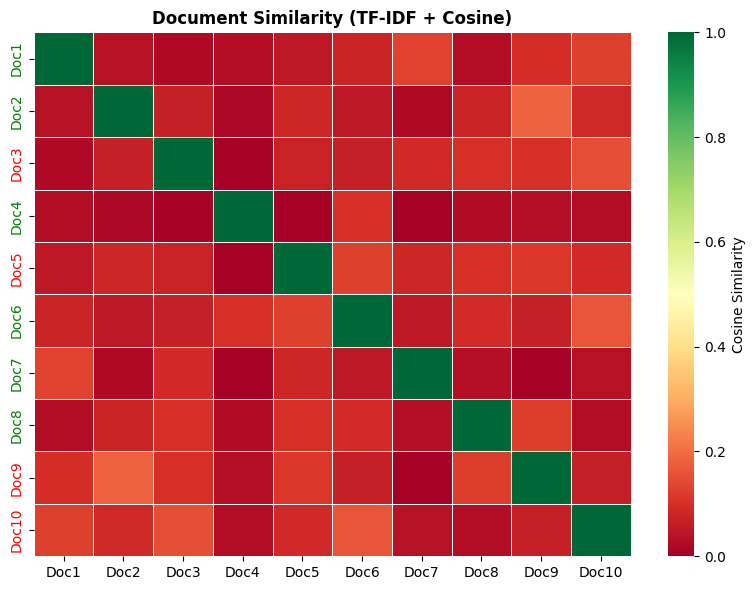


Most similar pair: Doc78 and Doc222 (similarity = 0.548)
  Doc78: actually didnt start watching show came fx bored nothing watch saw shows reruns premiering decided watch upset watched show aired tv loved show muchfi
  Doc222: little old show came young child childrens shows sesame street watch learned wasnt else cousins born years years came latter barney big part watched s


In [20]:
cosine_sim = cosine_similarity(tfidf_matrix)

# Slice 10x10
cos_10 = cosine_sim[:10, :10]

# Get sentiment labels for first 10 reviews
sentiments = sample_df['sentiment'].iloc[:10].tolist()

# Build labels
labels = [f'Doc{i+1}' for i in range(10)]

sim_df = pd.DataFrame(
    cos_10.round(3),
    index=labels,
    columns=labels
)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(sim_df, annot=False, cmap='RdYlGn',
                 linewidths=0.5, cbar_kws={'label': 'Cosine Similarity'})

plt.title('Document Similarity (TF-IDF + Cosine)', fontweight='bold')

# Color y-axis tick labels by sentiment
for tick, sentiment in zip(ax.get_yticklabels(), sentiments):
    tick.set_color('green' if sentiment == 'positive' else 'red')

plt.tight_layout()
plt.show()

# Most similar pair
cos_sim_copy = cosine_sim.copy()
np.fill_diagonal(cos_sim_copy, 0)
idx = np.unravel_index(np.argmax(cos_sim_copy), cos_sim_copy.shape)
print(f"\nMost similar pair: Doc{idx[0]+1} and Doc{idx[1]+1} (similarity = {cos_sim_copy[idx]:.3f})")
print(f"  Doc{idx[0]+1}: {sample_df['joined'].iloc[idx[0]][:150]}")
print(f"  Doc{idx[1]+1}: {sample_df['joined'].iloc[idx[1]][:150]}")

# **Logistic Regression Model Application on TF-IDF**

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

X = tfidf_matrix  # 300 rows
y = sample_df['sentiment']  # match with 300-row sample

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)

# Evaluate
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.80      0.65      0.71        31
    positive       0.69      0.83      0.75        29

    accuracy                           0.73        60
   macro avg       0.74      0.74      0.73        60
weighted avg       0.74      0.73      0.73        60

[[20 11]
 [ 5 24]]


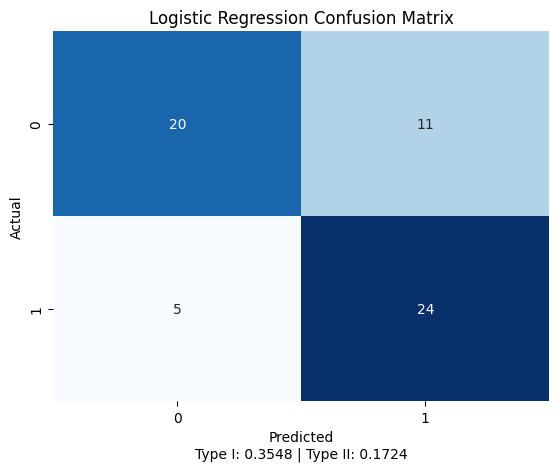

TP: 24 | TN: 20 | FP: 11 | FN: 5
Type I Error Rate:  35.4839%
Type II Error Rate: 17.2414%
Precision: 0.69 | Recall: 0.83

   Model  Accuracy  Precision  Recall  F1-Score
Logistic    0.7333     0.6857  0.8276    0.7500


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

type_i_error = fp / (fp + tn)
type_ii_error = fn / (fn + tp)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel(f'Predicted\nType I: {type_i_error:.4f} | Type II: {type_ii_error:.4f}')
plt.ylabel('Actual')
plt.show()

print(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")
print(f"Type I Error Rate:  {type_i_error:.4%}")
print(f"Type II Error Rate: {type_ii_error:.4%}")
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"Precision: {precision:.2f} | Recall: {recall:.2f}")

metrics_data = {
    'Model': ['Logistic'],
    'Accuracy': [accuracy_score(y_test, y_pred)],
    'Precision': [precision_score(y_test, y_pred, pos_label='positive')],
    'Recall': [recall_score(y_test, y_pred, pos_label='positive')],
    'F1-Score': [f1_score(y_test, y_pred, pos_label='positive')]
}

metrics_df = pd.DataFrame(metrics_data)
print()
print(metrics_df.to_string(index=False, float_format=lambda x: "{:.4f}".format(x)))

#### **Insights:**

- We managed to utilize a Logistic Regression model for the IMDB dataset because of the TF-IDF's vectorization of the reviews.
- TF-IDF managed to convert the text into readable numbers for the model making it able to create predictions on the dataset.
- The Logistic Regression model has a high accuracy score ``0.73`` which is good since the dataset is evenly balanced 50/50.
- It has a slightly lower precision score of ``0.69`` which goes to show that it has a slightly harder time correctly classifying positive sentiments.
- The recall score boasts a ``0.83`` score leading us to determine that it rarely misclassifies positive sentiments as negative.
- The F1-Score of ``0.75``reflects the model's ability to properly balance precision and recall, being able to correctly classify positive sentiments while at the same time rarely misclassifying positive as negative. 

### **References:**

Anthropic. (2025). Claude. Claude.ai. https://claude.ai/new <br>
Google. (2024). Gemini. Gemini.google.com. https://gemini.google.com

# ***Assessment 13***

In [26]:
# Load and Sample
df = pd.read_csv('IMDB Dataset.csv')
sample_df = df.sample(n=2000, random_state=42).reset_index(drop=True)
print("Sentiment Distribution:\n", sample_df['sentiment'].value_counts())

def preprocess(text):
    # a. Lowercase
    text = text.lower()
    # b. Remove HTML
    text = re.sub(r'<.*?>', '', text)
    # c. Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # d. Tokenize
    tokens = nltk.word_tokenize(text)
    # e. Stop words + Custom words
    stop_words = set(stopwords.words('english'))
    custom_words = {'film', 'movie', 'one', 'make', 'even', 'see', 'character'}
    tokens = [t for t in tokens if t not in stop_words and t not in custom_words]
    # f. Lemmatize
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(t) for t in tokens]

sample_df['clean_review'] = sample_df['review'].apply(preprocess)
# Join back for TF-IDF
sample_df['clean_text'] = sample_df['clean_review'].apply(lambda x: " ".join(x))

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1,2), min_df=3, max_df=0.90)
tfidf_matrix = tfidf.fit_transform(sample_df['clean_text'])
tfidf_norm = normalize(tfidf_matrix)

print(f"Matrix Shape: {tfidf_norm.shape}")

Sentiment Distribution:
 sentiment
negative    1024
positive     976
Name: count, dtype: int64
Matrix Shape: (2000, 2000)


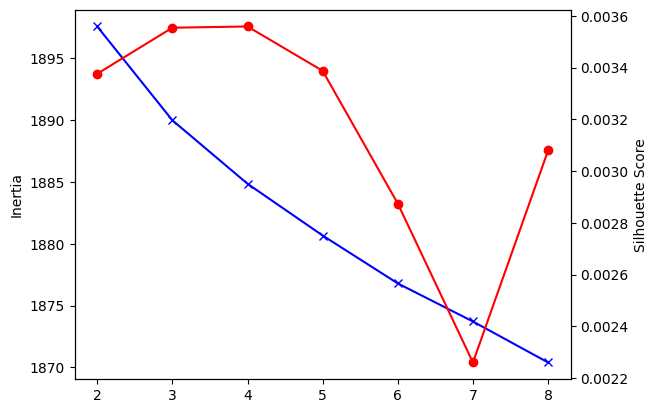

Cluster 0 Top Terms: ['bad', 'like', 'dont', 'time', 'good', 'seen', 'would', 'really', 'get', 'ever', 'movie', 'watch', 'could', 'acting', 'people']
Cluster 1 Top Terms: ['story', 'good', 'great', 'like', 'love', 'time', 'also', 'film', 'scene', 'well', 'get', 'life', 'character', 'really', 'man']
Cluster 2 Top Terms: ['show', 'episode', 'series', 'like', 'season', 'people', 'good', 'tv', 'funny', 'would', 'great', 'time', 'first', 'get', 'watch']


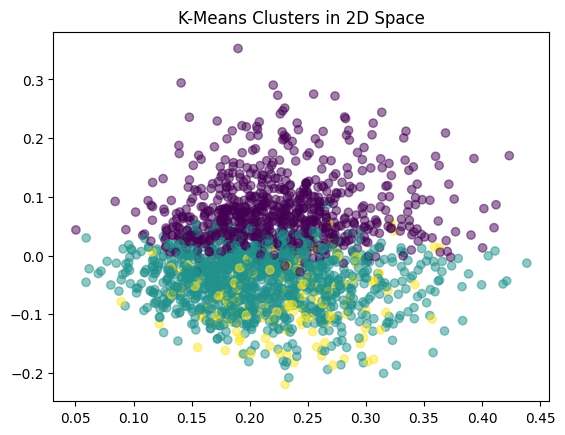

In [27]:
# Elbow & Silhouette
inertia = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(tfidf_norm)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(tfidf_norm, km.labels_))

# Plotting
fig, ax1 = plt.subplots()
ax1.plot(K_range, inertia, 'bx-')
ax1.set_ylabel('Inertia')
ax2 = ax1.twinx()
ax2.plot(K_range, sil_scores, 'ro-')
ax2.set_ylabel('Silhouette Score')
plt.show()

# Chosen K (Let's assume 3 or 4 based on the elbow/silhouette)
chosen_k = 3 
kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10).fit(tfidf_norm)
sample_df['cluster'] = kmeans.labels_

# Interpretation
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = tfidf.get_feature_names_out()
for i in range(chosen_k):
    print(f"Cluster {i} Top Terms:", [terms[ind] for ind in order_centroids[i, :15]])

# Visualization
svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(tfidf_norm)
plt.scatter(coords[:, 0], coords[:, 1], c=sample_df['cluster'], cmap='viridis', alpha=0.5)
plt.title("K-Means Clusters in 2D Space")
plt.show()

In [31]:
# Dictionary and Corpus
id2word = corpora.Dictionary(sample_df['clean_review'])
id2word.filter_extremes(no_below=3, no_above=0.85)
corpus = [id2word.doc2bow(text) for text in sample_df['clean_review']]

# Train LDA
lda_model = models.LdaModel(corpus=corpus, id2word=id2word, num_topics=4, 
                           passes=15, alpha='auto', eta='auto', random_state=42)

# Top Words Bar Chart
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
for i, ax in enumerate(axes.flatten()):
    words = dict(lda_model.show_topic(i, 10))
    ax.barh(list(words.keys()), list(words.values()))
    ax.set_title(f"Topic {i}")
plt.tight_layout()
plt.show()

NameError: name 'corpora' is not defined